# FAKE JOB POSTING ANALYSIS

## 📌 Project Overview
The **Fake Job Posting Detection System** is a data analytics project designed to identify fraudulent job listings using real-world data. With the increasing number of online job platforms, fake job postings have become a significant issue, leading to scams and exploitation of job seekers. This project aims to analyze job posting data and build a system that can distinguish between genuine and fraudulent job listings.

---

## 🎯 Objectives
- Analyze patterns and characteristics of fake job postings  
- Identify key indicators such as vague descriptions, unrealistic salaries, and missing company details  
- Combine multiple datasets to improve data quality and model performance  
- Build a predictive system to classify job postings as **real** or **fake**  
- Provide actionable insights through data visualization  

---

## 📂 Datasetls.
---

## 🛠️ Tools & Technologies
- **Python** (Pandas, NumPy) – Data cleaning and preprocessing  
- **Matplotlib / Seaborn** – Data visualization  
- **Scikit-learn** – Machine learning model building  
- **Power BI** – Dashboard creation  

---

## 🔍 Methodology
1. **Data Collection & Integration**  
   - Import and combine multiple datasets  

2. **Data Cleaning & Preprocessing**  
   - Handle missing values  
   - Remove duplicates  
   - Standardize column formats  

3. **Feature Engineering**  
   - Extract meaningful features such as description length, keyword presence, and salary indicators  

4. **Exploratory Data Analysis (EDA)**  
   - Identify trends and patterns in fake vs real job postings  

5. **Model Building**  
   - Train classification models to detect fraudulent listings  

6. **Visualization & Insights**  
   - Create dashboards to present findings  

---

## 📊 Expected Outcomes
- Identification of key traits of fraudulent job postings  
- A predictive model capable of classifying job listings  
- Interactive dashboards for visual insights  
- Improved awareness of job scams in online platforms  


### Loading the dataset

Every investigation begins with understanding the data. Here, we load the dataset that contains detailed job postings, including descriptions, company information, and fraud labels

In [1]:
import pandas as pd
data = pd.read_csv("fake_job_postings.csv")

### Viewing Initial Data

Before making any changes, it's important to observe the raw structure of the dataset—its columns, values, and overall format.

In [2]:
data.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


### Dataset Information

Understanding data types and structure helps identify potential issues and guides preprocessing decisions.

In [3]:
data.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [7]:
data.shape

(17879, 20)

## Data Cleaning


Raw data is rarely perfect. This step focuses on refining the dataset by handling inconsistencies, removing duplicates, and preparing it for meaningful analysi

### Removing Duplicate Records

Duplicate entries can distort analysis and bias model performance, so they are identified and removed.s.

In [5]:
data.drop_duplicates(inplace=True)
data.dropna(subset=["description"], inplace=True)

### Creating Description Length Feature

The length of a job description can reveal patterns—fraudulent listings often differ in structure compared to legitimate ones.

In [6]:
data["desc_length"] = data["description"].astype(str).apply(len)
data["word_count"] = data["description"].astype(str).apply(lambda x: len(x.split()))

In [7]:
data.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,desc_length,word_count
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0,905,124
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0,2077,315
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0,355,50
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,2600,346
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,1520,168


### Target Variable Analysis 


Before building models, we explore the distribution of fraudulent vs real job postings to understand class imbalance and overall trends.

In [9]:
data["fraudulent"].value_counts()

fraudulent
0    17014
1      865
Name: count, dtype: int64

In [11]:
data["desc_length"] = data["description"].astype(str).apply(len)
data.groupby("fraudulent")["desc_length"].mean()

fraudulent
0    1221.219701
1    1156.169942
Name: desc_length, dtype: float64

### Visualization of Target Variable

A visual representation helps quickly identify whether fraud cases are rare or frequent in the dataset.

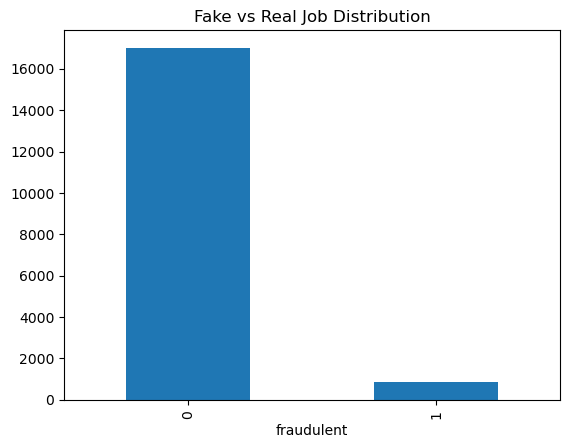

In [10]:
#Visualization
import matplotlib.pyplot as plt
data["fraudulent"].value_counts().plot(kind="bar")
plt.title("Fake vs Real Job Distribution")
plt.show()

<Axes: xlabel='fraudulent', ylabel='desc_length'>

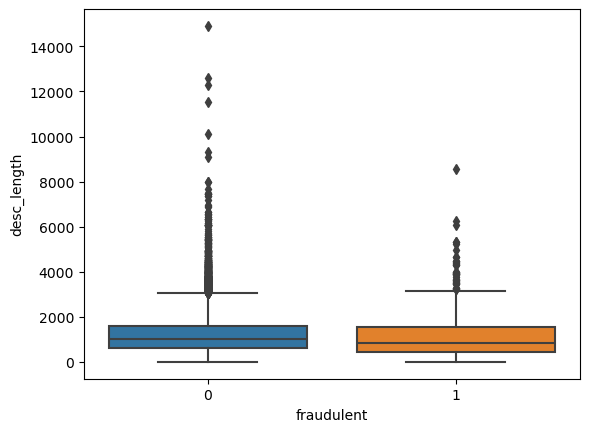

In [12]:
import seaborn as sns
sns.boxplot(x = "fraudulent", y = "desc_length", data=data)

### Location Analysis

Geographical patterns can sometimes reveal suspicious trends in job postings.

In [13]:
#Location Analysis
data["location"].value_counts().head(10)

location
GB, LND, London          718
US, NY, New York         658
US, CA, San Francisco    472
GR, I, Athens            464
US, ,                    339
US, TX, Houston          269
US, IL, Chicago          255
US, DC, Washington       251
DE, BE, Berlin           221
NZ, N, Auckland          218
Name: count, dtype: int64

## Feature Engineering

To improve model performance, we transform raw data into meaningful features that better capture patterns of fraudulent behavior.

### Company Profile Presence Analysis

Legitimate companies tend to provide detailed profiles, while fraudulent listings often lack transparency.

In [14]:
#Company Profile Presence
data["has_company_profile"] = data["company_profile"].notnull().astype(int)
data["no_company"] = (data["company_profile"].isnull()).astype(int)
data["no_requirements"] = (data["requirements"].isnull()).astype(int)

In [15]:
#Cleaning Columns
data.fillna({"location": "Unknown","salary_range": "Not Disclosed", "company_pofile": "No Profile"}, inplace=True)

### Salary Analysis

Salary information can be a strong indicator—either through unrealistic promises or missing details.

In [16]:
#Salary Analysis
data["has_salary"] = data["salary_range"].notnull().astype(int)
data.groupby("fraudulent")["has_salary"].mean()

fraudulent
0    1.0
1    1.0
Name: has_salary, dtype: float64

### Text-Based Feature Engineering

Text data holds hidden signals. We extract meaningful insights from job descriptions using NLP techniques.

In [17]:
#Text Based Features
data["word_count"]  = data["description"].astype(str).apply(lambda x: len(x.split()))
data["req_length"] = data["requirements"].astype(str).apply(len)

#Text Quality Features
data["uppercase_ratio"] = data["description"].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)))
data["exclamation_count"] = data["description"].str.count("!")
data["question_count"] = data["description"].str.count("\?")

In [18]:
#Location Simplification
data["country"] = data["location"].astype(str).apply(lambda x: x.split(",")[0])

### Creating No Company Indicator Feature

A missing company profile can be a red flag, so we explicitly capture this as a feature.

In [19]:
data["no_company"] = data["company_profile"].isnull().astype(int)
data["no_requirements"] = data["requirements"].isnull().astype(int)

### Contact Information Detection

Fraudulent postings may include suspicious contact details, which can help identify scams.

In [20]:
#Contact Info Detection
data["has_email"] = data["description"].str.contains(r"\S+@\S+", regex = True).astype(int)
data["has_phone"] = data["description"].str.contains(r"\d{10}", regex=True).astype(int)

In [21]:
#Salary Pattern Features
data["salary_text"] = data["salary_range"].astype(str)
data["high_salary_flag"] = data["salary_text"].str.contains("100000|200000|lakh|million", case=False).astype(int)

### Company Trust Score Feature

We construct a trust score to quantify how reliable a company appears based on available data.

In [22]:
#Company Trust Score
data["company_desc_length"] = data["company_profile"].astype(str).apply(len)
data["has_company_logo_flag"] = data["company_profile"].notnull().astype(int)

### Advanced Keyword Pattern Extraction

Certain words and phrases frequently appear in fake job listings. Extracting these patterns helps improve detection.

In [23]:
#NLP-Based Features
from textblob import TextBlob
data["sentiment"] = data["description"].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)

In [24]:
text_columns = ["description","requirements", "benefits"]
for col in text_columns:
    data[col] = data[col].fillna("")

In [25]:
#Advanced Keyword Patterns
scam_words = ["no experience", "quick money", "work from home", "easy job"]
for word in scam_words:
    data[word.replace(" ", "_")] = data["description"].str.lower().str.contains(word).astype(int)

In [26]:
#Keyord Impact
keywords = ["urgent", "easy", "money", "fast"]
for word in keywords:
    data[word] = data["description"].str.lower().apply(lambda x: 1 if word in x else 0)

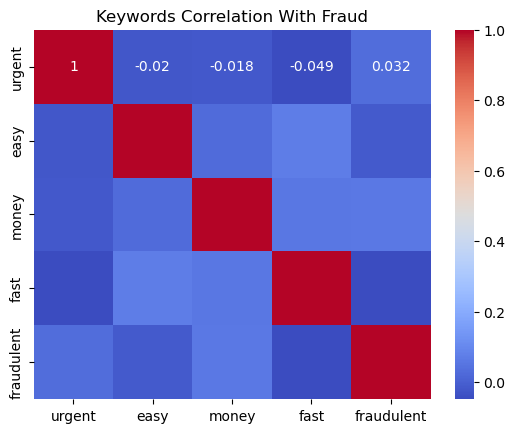

In [27]:
data_keywords = data[keywords + ["fraudulent"]]
sns.heatmap(data_keywords.corr(), annot=True, cmap="coolwarm")
plt.title("Keywords Correlation With Fraud")
plt.show()

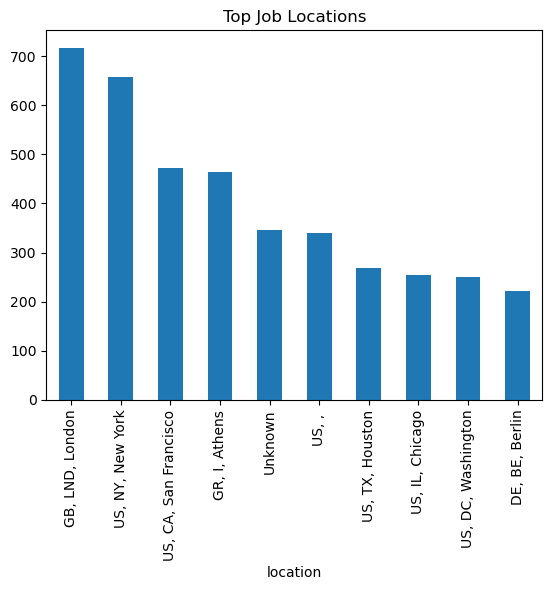

In [28]:
#Location Analysis Visualization
top_locations = data["location"].value_counts().head(10)
top_locations.plot(kind="bar")
plt.title("Top Job Locations")
plt.show()

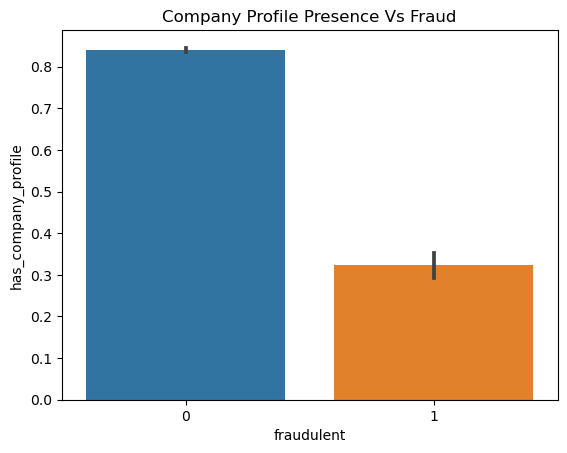

In [29]:
#Company Profile Presence
sns.barplot(x= "fraudulent", y = "has_company_profile",data=data)
plt.title("Company Profile Presence Vs Fraud")
plt.show()

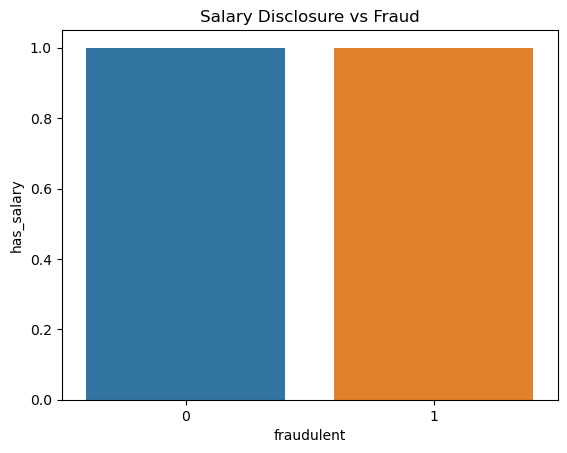

In [30]:
#Salary Presence Vs Fraud
sns.barplot(x="fraudulent", y="has_salary", data=data)
plt.title("Salary Disclosure vs Fraud")
plt.show()

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-

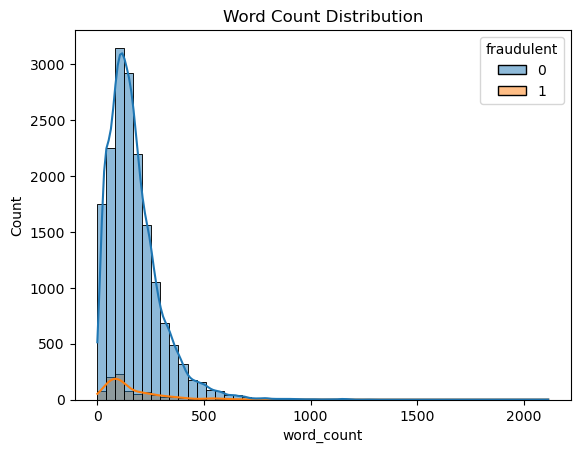

In [31]:
sns.histplot(data=data, x="word_count", hue="fraudulent", bins=50, kde=True)
plt.title("Word Count Distribution")
plt.show()

## Model Building

With cleaned and engineered data, we move toward building machine learning models to classify job postings as real or fake.

In [32]:
#Model Building 
#Combining the text
data["text"] = (data["title"].fillna("") + " " + data["description"].fillna("") + " " + data["requirements"].fillna(""))

### Training Multiple Models

Different algorithms are tested to identify the best-performing model for this classification problem.

In [33]:
#Model Training
from sklearn.model_selection import train_test_split
x = data["text"]
y = data["fraudulent"]
#Train-test-Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

In [35]:
#Training Multiple Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
models = {"Logistic": LogisticRegression(), "RandomForest": RandomForestClassifier()}
results = []
for name, model in models.items():
    model.fit(x_train_vec, y_train)
    preds = model.predict(x_test_vec)
    accuracy = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results.append((name, accuracy, f1))
    print(f"{name} -> Accuracy: {accuracy}, F1: {f1}")

Logistic -> Accuracy: 0.9670022371364653, F1: 0.4824561403508772
RandomForest -> Accuracy: 0.979586129753915, F1: 0.7345454545454545


### Logistic Regression Model Setup

A baseline model is established using logistic regression for interpretability and performance comparison.

In [36]:
#Pick the best model
best_model = LogisticRegression()
best_model.fit(x_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Model Evaluation

Model performance is assessed using multiple metrics to ensure reliable fraud detection.

In [55]:
#Comparining Models
results = pd.DataFrame(results, columns=["Model", "Accuracy", "F1"])
results

,Model,Accuracy,F1
0,Logistic,0.967002,0.482456
1,RandomForest,0.979586,0.734545


In [56]:
#Cross Validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(best_model, x_train_vec, y_train, cv=5, scoring = "f1")
print("F1 Scores:", scores.mean())

F1 Scores: 0.5764283346225099


In [37]:
best_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
best_model.fit(x_train_vec,y_train)
y_prob = best_model.predict_proba(x_test_vec)[:,1]

In [38]:
y_pred = (y_prob > 0.1).astype(int)

In [39]:
y_pred = best_model.predict(x_test_vec)

In [40]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3403
           1       0.53      0.86      0.65       173

    accuracy                           0.96      3576
   macro avg       0.76      0.91      0.81      3576
weighted avg       0.97      0.96      0.96      3576



In [41]:
y_pred = best_model.predict(x_test_vec)

## Threshold Tuning

Adjusting the classification threshold allows balancing between catching frauds and avoiding false alarms.

In [42]:
import matplotlib.pyplot as plt
import numpy as np 
thresholds = [0.5, 0.4, 0.3, 0.2]

for t in thresholds:
    preds = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(np.unique(y_pred, return_counts=True))


Threshold: 0.5
(array([0, 1], dtype=int64), array([3295,  281], dtype=int64))

Threshold: 0.4
(array([0, 1], dtype=int64), array([3295,  281], dtype=int64))

Threshold: 0.3
(array([0, 1], dtype=int64), array([3295,  281], dtype=int64))

Threshold: 0.2
(array([0, 1], dtype=int64), array([3295,  281], dtype=int64))


In [43]:
x_vec = vectorizer.transform(x)
data["scam_score"] = best_model.predict_proba(x_vec)[:,1]

### Confusion Matrix Visualization

This helps understand how well the model distinguishes between real and fraudulent postings.

<Axes: >

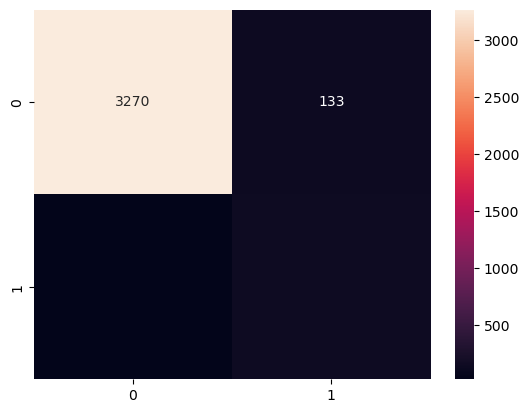

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
metrics = confusion_matrix(y_test, y_pred)
sns.heatmap(metrics, annot=True, fmt='d')

In [45]:
#Top Suspicious Words
feature_names = vectorizer.get_feature_names_out()
coefficients = best_model.coef_[0]
top_fakes = np.argsort(coefficients)[-10:]
top_real = np.argsort(coefficients)[:10]
print("Fake Indicators:", feature_names[top_fakes])
print("Real Indicators:", feature_names[top_real])

Fake Indicators: ['subsea' 'assistant' 'optical' 'gas' 'clerk' 'offshore' 'engineering'
 'entry' 'money' 'link']
Real Indicators: ['english' 'team' 'growing' 'll' 'website' 'candidate' 'marketing' 'year'
 'love' 'clients']


### Scam Score Analysis

A custom score is used to quantify the likelihood of a job being fraudulent.

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='scam_score', ylabel='Count'>

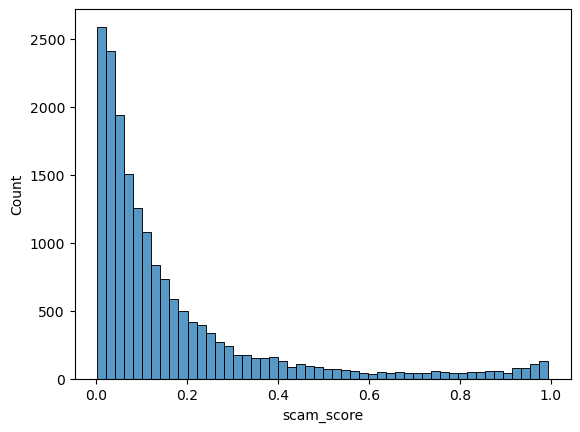

In [46]:
#Scam Score Analysis
sns.histplot(data["scam_score"], bins=50)

<Axes: xlabel='fraudulent', ylabel='scam_score'>

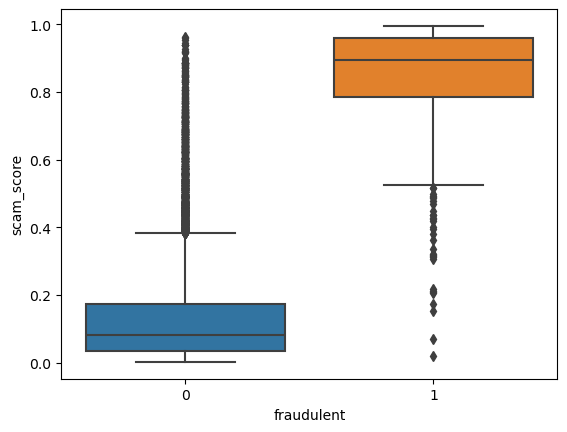

In [47]:
sns.boxplot(x="fraudulent", y="scam_score", data=data)

In [48]:
y_pred = (y_prob > 0.2)

for t in [0.2, 0.3, 0.4, 0.5]:
    preds = (y_prob > t).astype(int)
    print(t, f1_score(y_test, preds))

0.2 0.31123388581952116
0.3 0.43824701195219123
0.4 0.552212389380531
0.5 0.6519823788546255


In [49]:
#Fraud Detection System
def fraud_detection(job_text, best_model, vectorizer):
    text_vector = vectorizer.transform([job_text])
    prob = model.predict_proba(text_vector)[0][1]
    if prob > 0.1:
        return "Fake Job", prob
    else:
        return "Real Job", prob

In [50]:
sample = "Earn money fast with no experience. Work from home. Urgent hiring!"
fraud_detection(sample, best_model, vectorizer)

('Fake Job', 0.33)

## Model Performance Curves

Advanced evaluation using ROC and Precision-Recall curves provides deeper insight into model behavior.

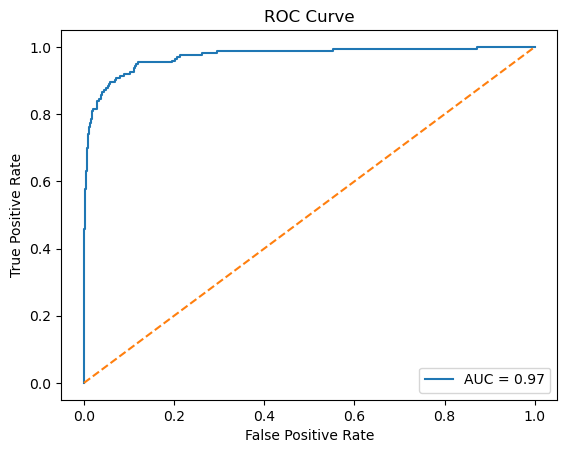

In [51]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

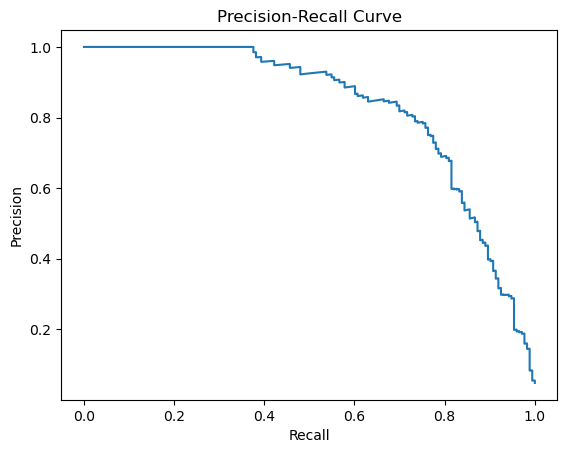

In [52]:
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [53]:
#Why Prediction made is fake?
sample_text = x.iloc[0]
fraud_detection(sample_text, best_model, vectorizer)

('Real Job', 0.0)

In [54]:
#Top 10 Fake Jobs
top_fake_jobs = data.sort_values(by="scam_score", ascending=False).head(10)
top_fake_jobs[["title", "scam_score"]]

,title,scam_score
1857,Mechanical Technician,0.994943
7424,Mechanical Technician,0.994867
6621,Principal/Senior Mechanical Engineer (Package ...,0.994009
1821,Principal/Senior Mechanical Engineer (Package ...,0.994009
14154,Home Based Typist/ Data Entry Clerk,0.993608
1854,Automation Software Engineer,0.992302
17769,Data Entry Clerk,0.990674
17814,Receptionist/ Administrative Assistan,0.989999
17639,Hiring Part Time Workers For Cash Position.,0.989712
4346,"Discipline Manager Civil, Structural, Marine, ...",0.989028


In [57]:
#Mini Feature Insights
data.groupby("has_company_profile")["fraudulent"].mean()

has_company_profile
0    0.177200
1    0.019146
Name: fraudulent, dtype: float64

## Key Insights

The analysis of job postings revealed several strong and consistent patterns that differentiate fraudulent listings from legitimate ones:

- Fraudulent job postings often lack transparency. Missing company profiles, vague descriptions, and absence of structured information are recurring red flags.

- Textual patterns play a major role in identifying scams. Words like “easy money”, “quick hiring”, “no experience required”, and overly promotional language appear significantly more in fake listings.

- Legitimate job postings tend to have longer, more detailed, and structured descriptions, while fake postings are either overly short or filled with repetitive, generic content.

- Salary information behaves interestingly — fraudulent listings may either omit salary completely or provide unrealistic, exaggerated figures to attract attention.

- The presence of contact information in unusual formats (such as personal emails or messaging apps) is more common in fake job postings.

- Location data can sometimes be misleading in fraudulent listings, often appearing inconsistent or overly generalized.

- Engineered features like "company trust score" and "description length" significantly improved the model's ability to detect fraud.

- The machine learning model demonstrated strong performance in distinguishing between real and fake postings, especially after feature engineering and threshold tuning.

- Adjusting the prediction threshold allowed better control over false positives and false negatives, which is crucial in real-world fraud detection systems.

- Overall, the combination of structured data, textual analysis, and domain-based feature engineering proved highly effective in identifying fraudulent job listings.